In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [5]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [6]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 39)
X_test: (1407, 39)
y_train: (5625,)
y_test: (1407,)


In [7]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [12]:
X_train = pd.get_dummies(X_train, columns=["tenure_group"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["tenure_group"], drop_first=True)

# Align columns to avoid mismatch
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [13]:
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [14]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



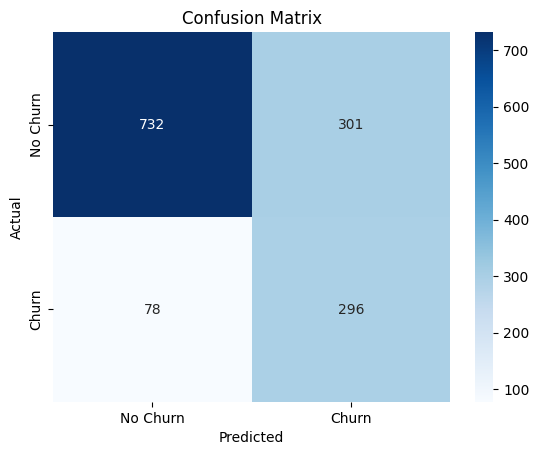

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
roc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc)

ROC AUC Score: 0.836881571250343


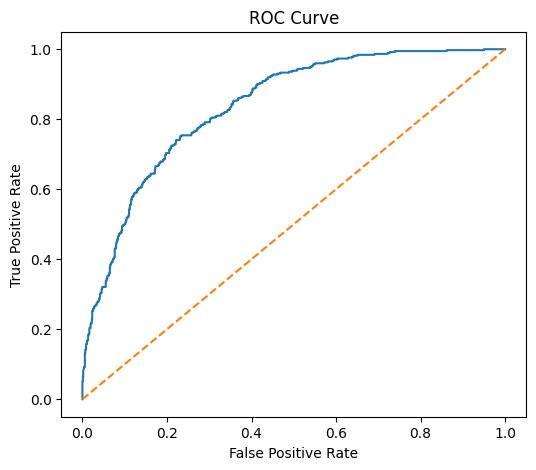

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [19]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["abs_coef"] = coefficients["Coefficient"].abs()

coefficients.sort_values("abs_coef", ascending=False).head(15)

,Feature,Coefficient,abs_coef
10,avg_monthly_spend,-1.093202,1.093202
3,TotalCharges,0.880170,0.880170
1,tenure,-0.863901,0.863901
7,fiber_customer,0.779370,0.779370
33,Contract_Two year,-0.623164,0.623164
4,service_count,0.592668,0.592668
8,long_contract,-0.550413,0.550413
9,customer_lifetime_value,-0.465124,0.465124
29,StreamingTV_Yes,0.430266,0.430266
31,StreamingMovies_Yes,0.412947,0.412947


In [20]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, rf_pred))

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC AUC:", rf_auc)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407

Random Forest ROC AUC: 0.8211752799333233


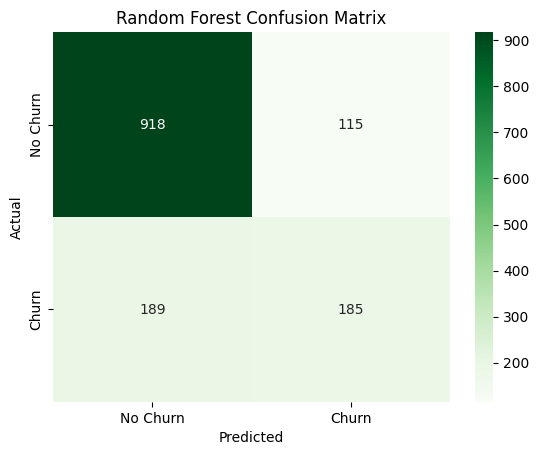

In [21]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [22]:
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importances = importances.sort_values(
    "Importance",
    ascending=False
)

importances.head(15)

,Feature,Importance
3,TotalCharges,0.101191
9,customer_lifetime_value,0.099908
10,avg_monthly_spend,0.093712
2,MonthlyCharges,0.091961
1,tenure,0.091488
8,long_contract,0.077884
33,Contract_Two year,0.040673
7,fiber_customer,0.025587
11,support_dependency,0.025131
18,InternetService_Fiber optic,0.024457


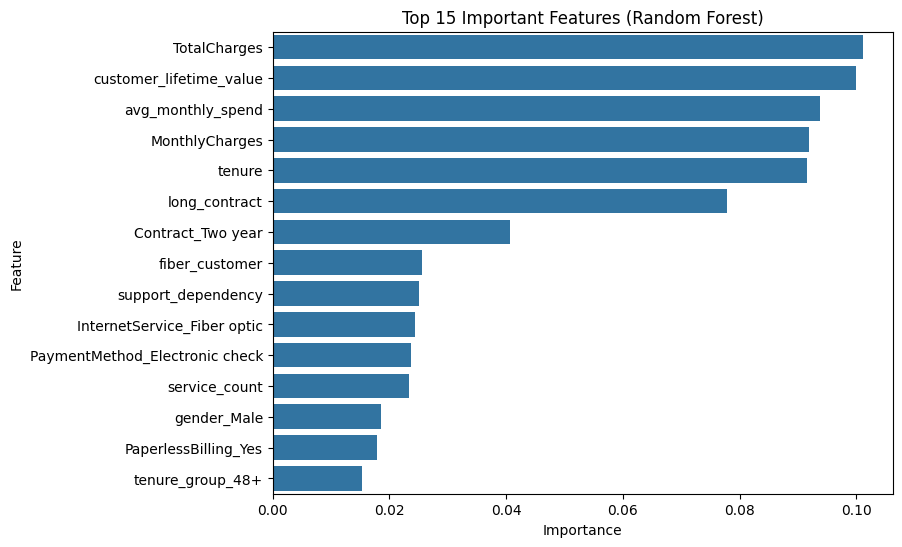

In [23]:
top_features = importances.head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features (Random Forest)")

plt.show()

In [24]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC_AUC": [roc, rf_auc]
})

comparison

,Model,ROC_AUC
0,Logistic Regression,0.836882
1,Random Forest,0.821175


In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:,1]

print(classification_report(y_test, gb_pred))

gb_auc = roc_auc_score(y_test, gb_prob)

print("Gradient Boosting ROC AUC:", gb_auc)

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

Gradient Boosting ROC AUC: 0.8385407229863697


In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC_AUC": [
        roc,
        rf_auc,
        gb_auc
    ]
})

comparison.sort_values("ROC_AUC", ascending=False)

,Model,ROC_AUC
2,Gradient Boosting,0.838541
0,Logistic Regression,0.836882
1,Random Forest,0.821175


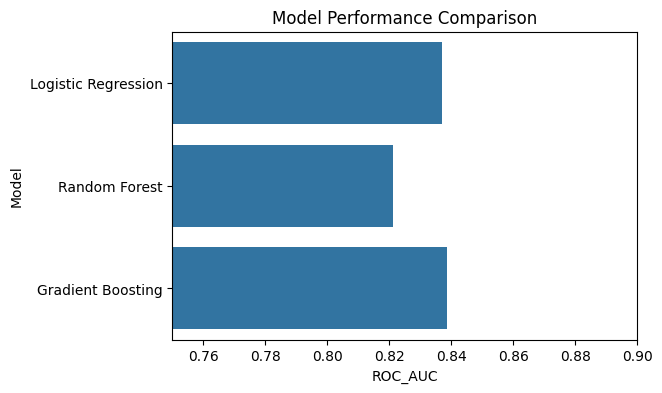

In [27]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="ROC_AUC",
    y="Model"
)

plt.title("Model Performance Comparison")

plt.xlim(0.75,0.90)

plt.show()

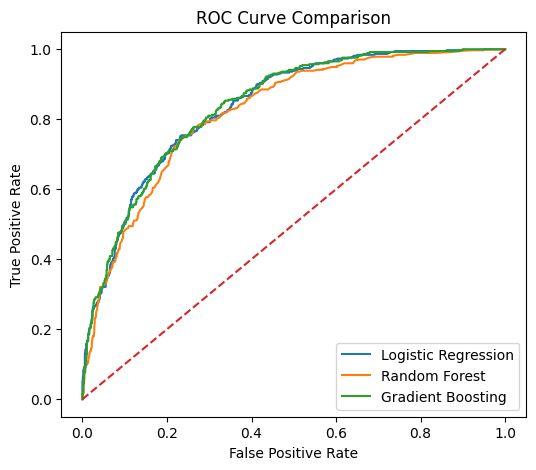

In [30]:
plt.figure(figsize=(6,5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [28]:
gb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb.feature_importances_
})

gb_importance = gb_importance.sort_values(
    "Importance",
    ascending=False
)

gb_importance.head(15)

,Feature,Importance
8,long_contract,0.385513
1,tenure,0.118806
3,TotalCharges,0.067684
2,MonthlyCharges,0.067132
18,InternetService_Fiber optic,0.048345
36,PaymentMethod_Electronic check,0.047383
10,avg_monthly_spend,0.046521
9,customer_lifetime_value,0.045055
7,fiber_customer,0.043109
21,OnlineSecurity_Yes,0.014264


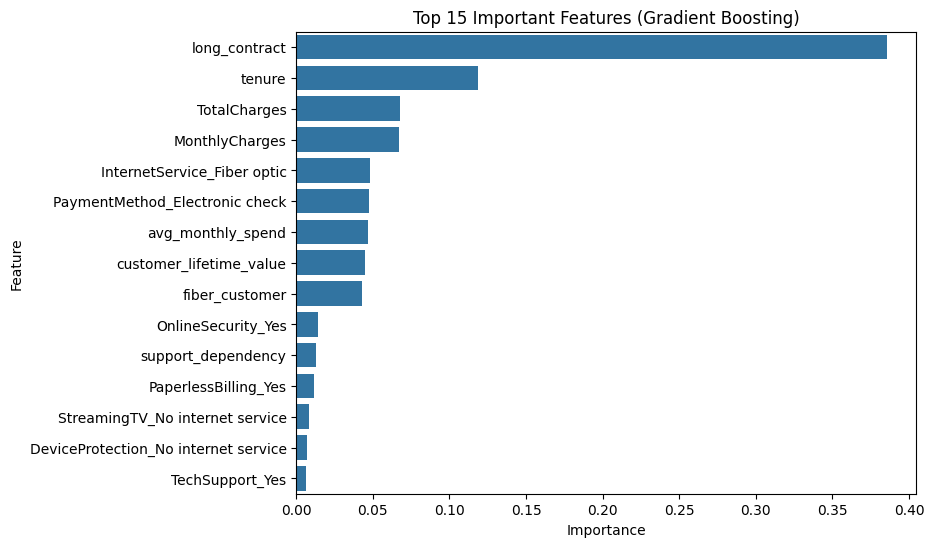

In [29]:
top_features = gb_importance.head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features (Gradient Boosting)")

plt.show()

In [31]:
best_model = gb

In [33]:
import joblib

joblib.dump(best_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']